# This notebook demonstrates the usage of the SMILE algorithm on a dummy dataset. Replace the dummy dataset with your own data to apply the method in practice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
from SMILE import SMILE

X, _ = make_blobs(n_samples=5000, centers=6, n_features=10, random_state=42)

print(X.shape) # Dummy dataset

(5000, 10)


In [2]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_embedded = tsne.fit_transform(X)

print(X_embedded.shape) #2D feature embeddings

(5000, 2)


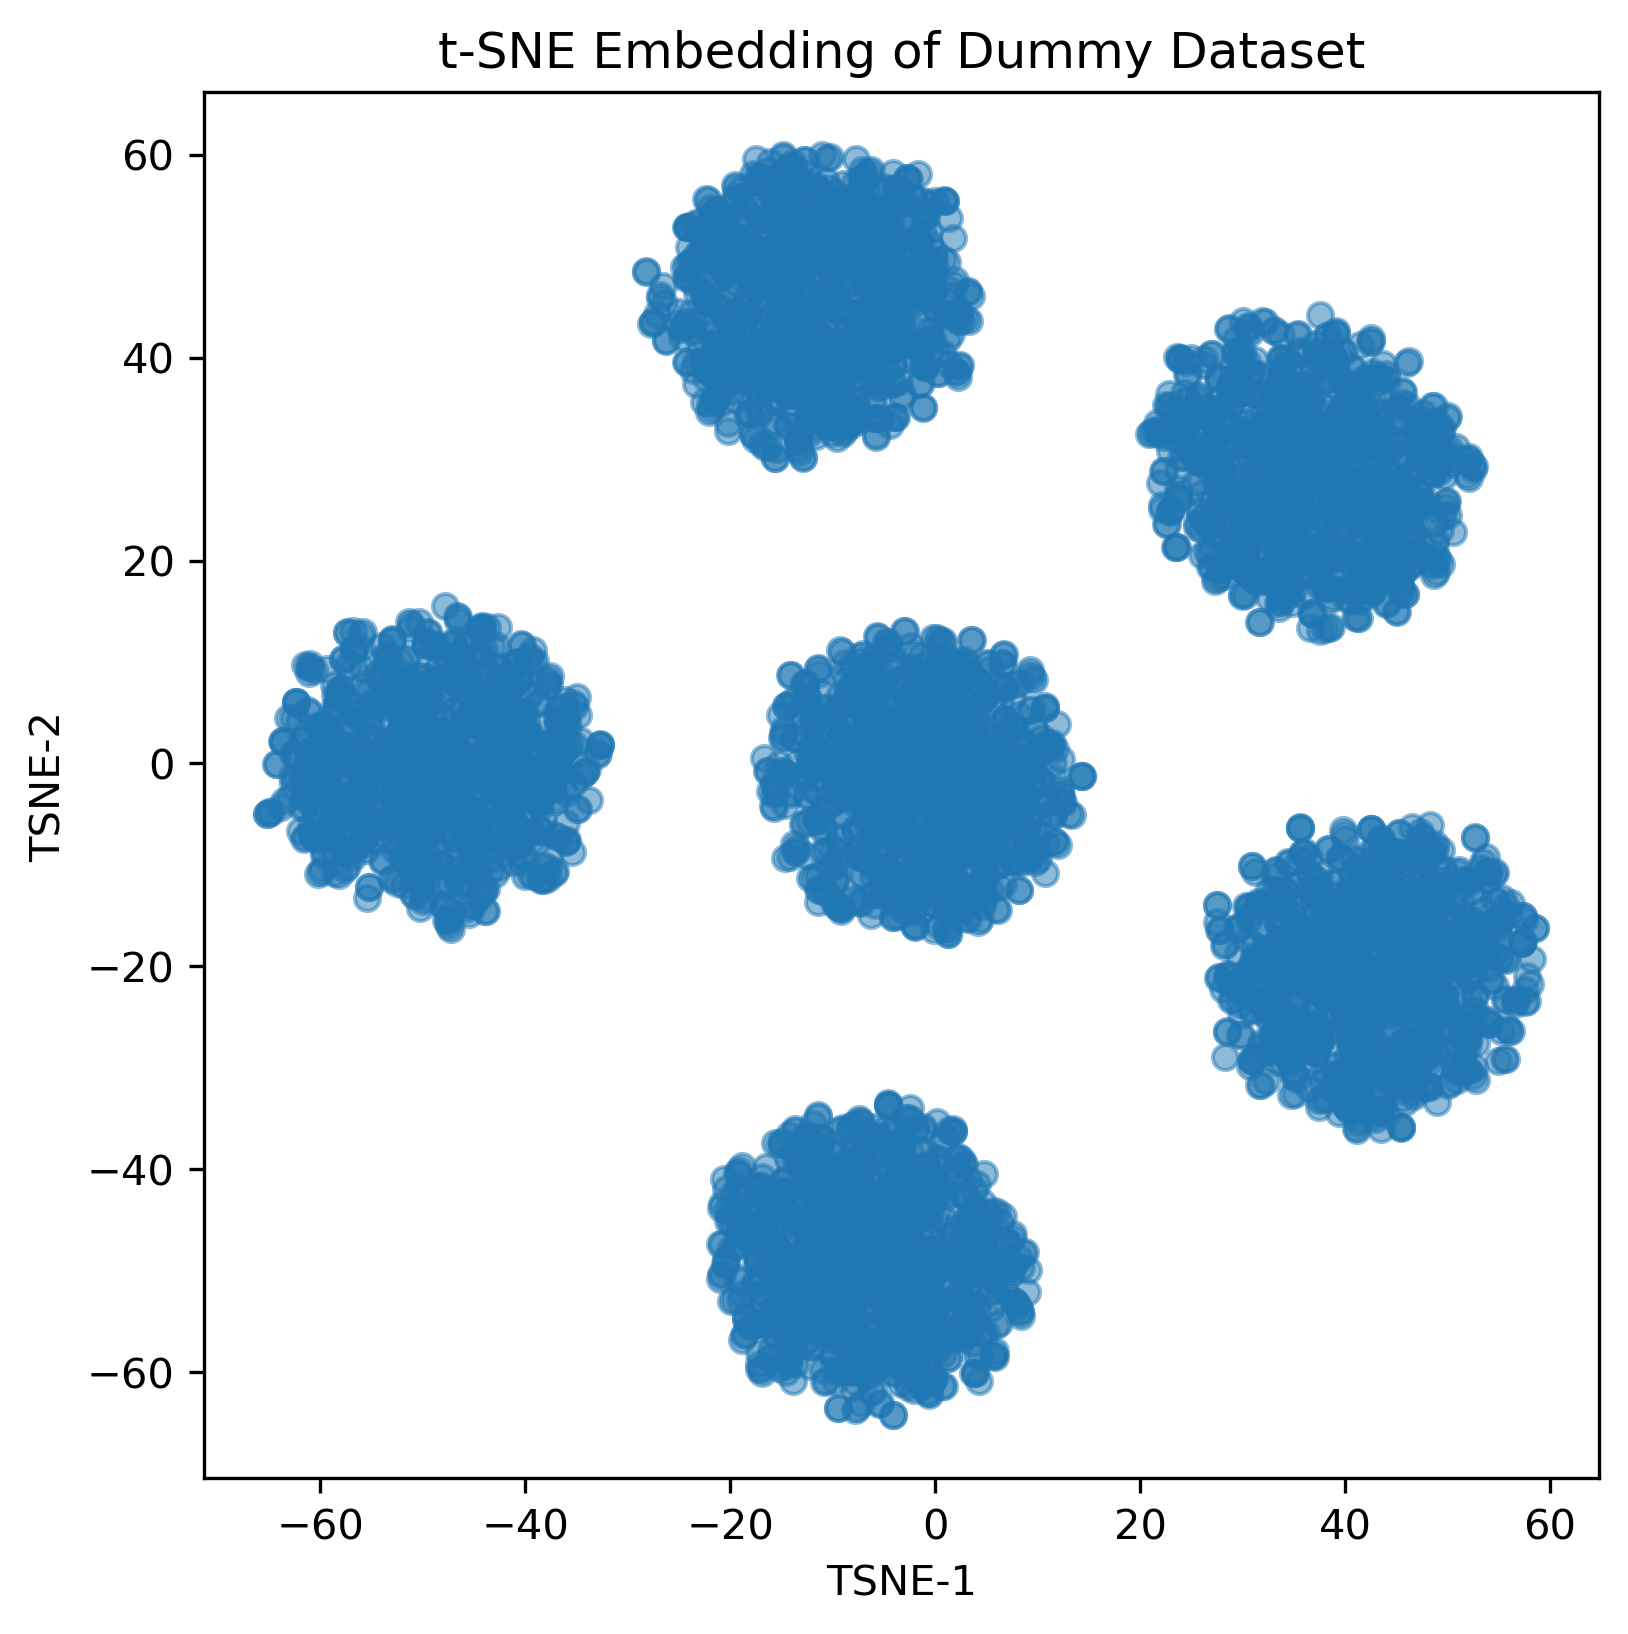

In [3]:
plt.figure(figsize=(6,6),dpi=300)
plt.scatter(X_embedded[:,0], X_embedded[:,1], alpha=0.5)
plt.title("t-SNE Embedding of Dummy Dataset")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.show()

In [4]:
selector = SMILE(n_clusters=6, k=10, random_state=42, verbose=False) # Use SMILE

selector.fit(X_embedded)

{0: array([ 327,  588, 1135, 3229,  357,  105,  129, 1657, 1565, 1000]),
 1: array([ 655,  722, 1168, 1295,  382,   21,  294,  206, 1748, 4262]),
 2: array([1261,  748,  529,  395,  498,  427,  419,  980, 3920,   92]),
 3: array([ 540,  243,  326, 1194,  171,  402,  439, 1694,  269,   53]),
 4: array([1301,  635,  444,  230,  234,  658,  127, 2049,  183,  884]),
 5: array([3960,  713,  560, 1006,   52,   60,  130,  589,  976,  602])}

In [5]:
selected_indices = selector.get_selected_indices() # Get the indices

print(selected_indices)

{0: array([ 327,  588, 1135, 3229,  357,  105,  129, 1657, 1565, 1000]), 1: array([ 655,  722, 1168, 1295,  382,   21,  294,  206, 1748, 4262]), 2: array([1261,  748,  529,  395,  498,  427,  419,  980, 3920,   92]), 3: array([ 540,  243,  326, 1194,  171,  402,  439, 1694,  269,   53]), 4: array([1301,  635,  444,  230,  234,  658,  127, 2049,  183,  884]), 5: array([3960,  713,  560, 1006,   52,   60,  130,  589,  976,  602])}


In [6]:
selected_points = []

for cluster_id, indices in selected_indices.items():
    selected_points.extend(indices)

selected_points = np.array(selected_points)

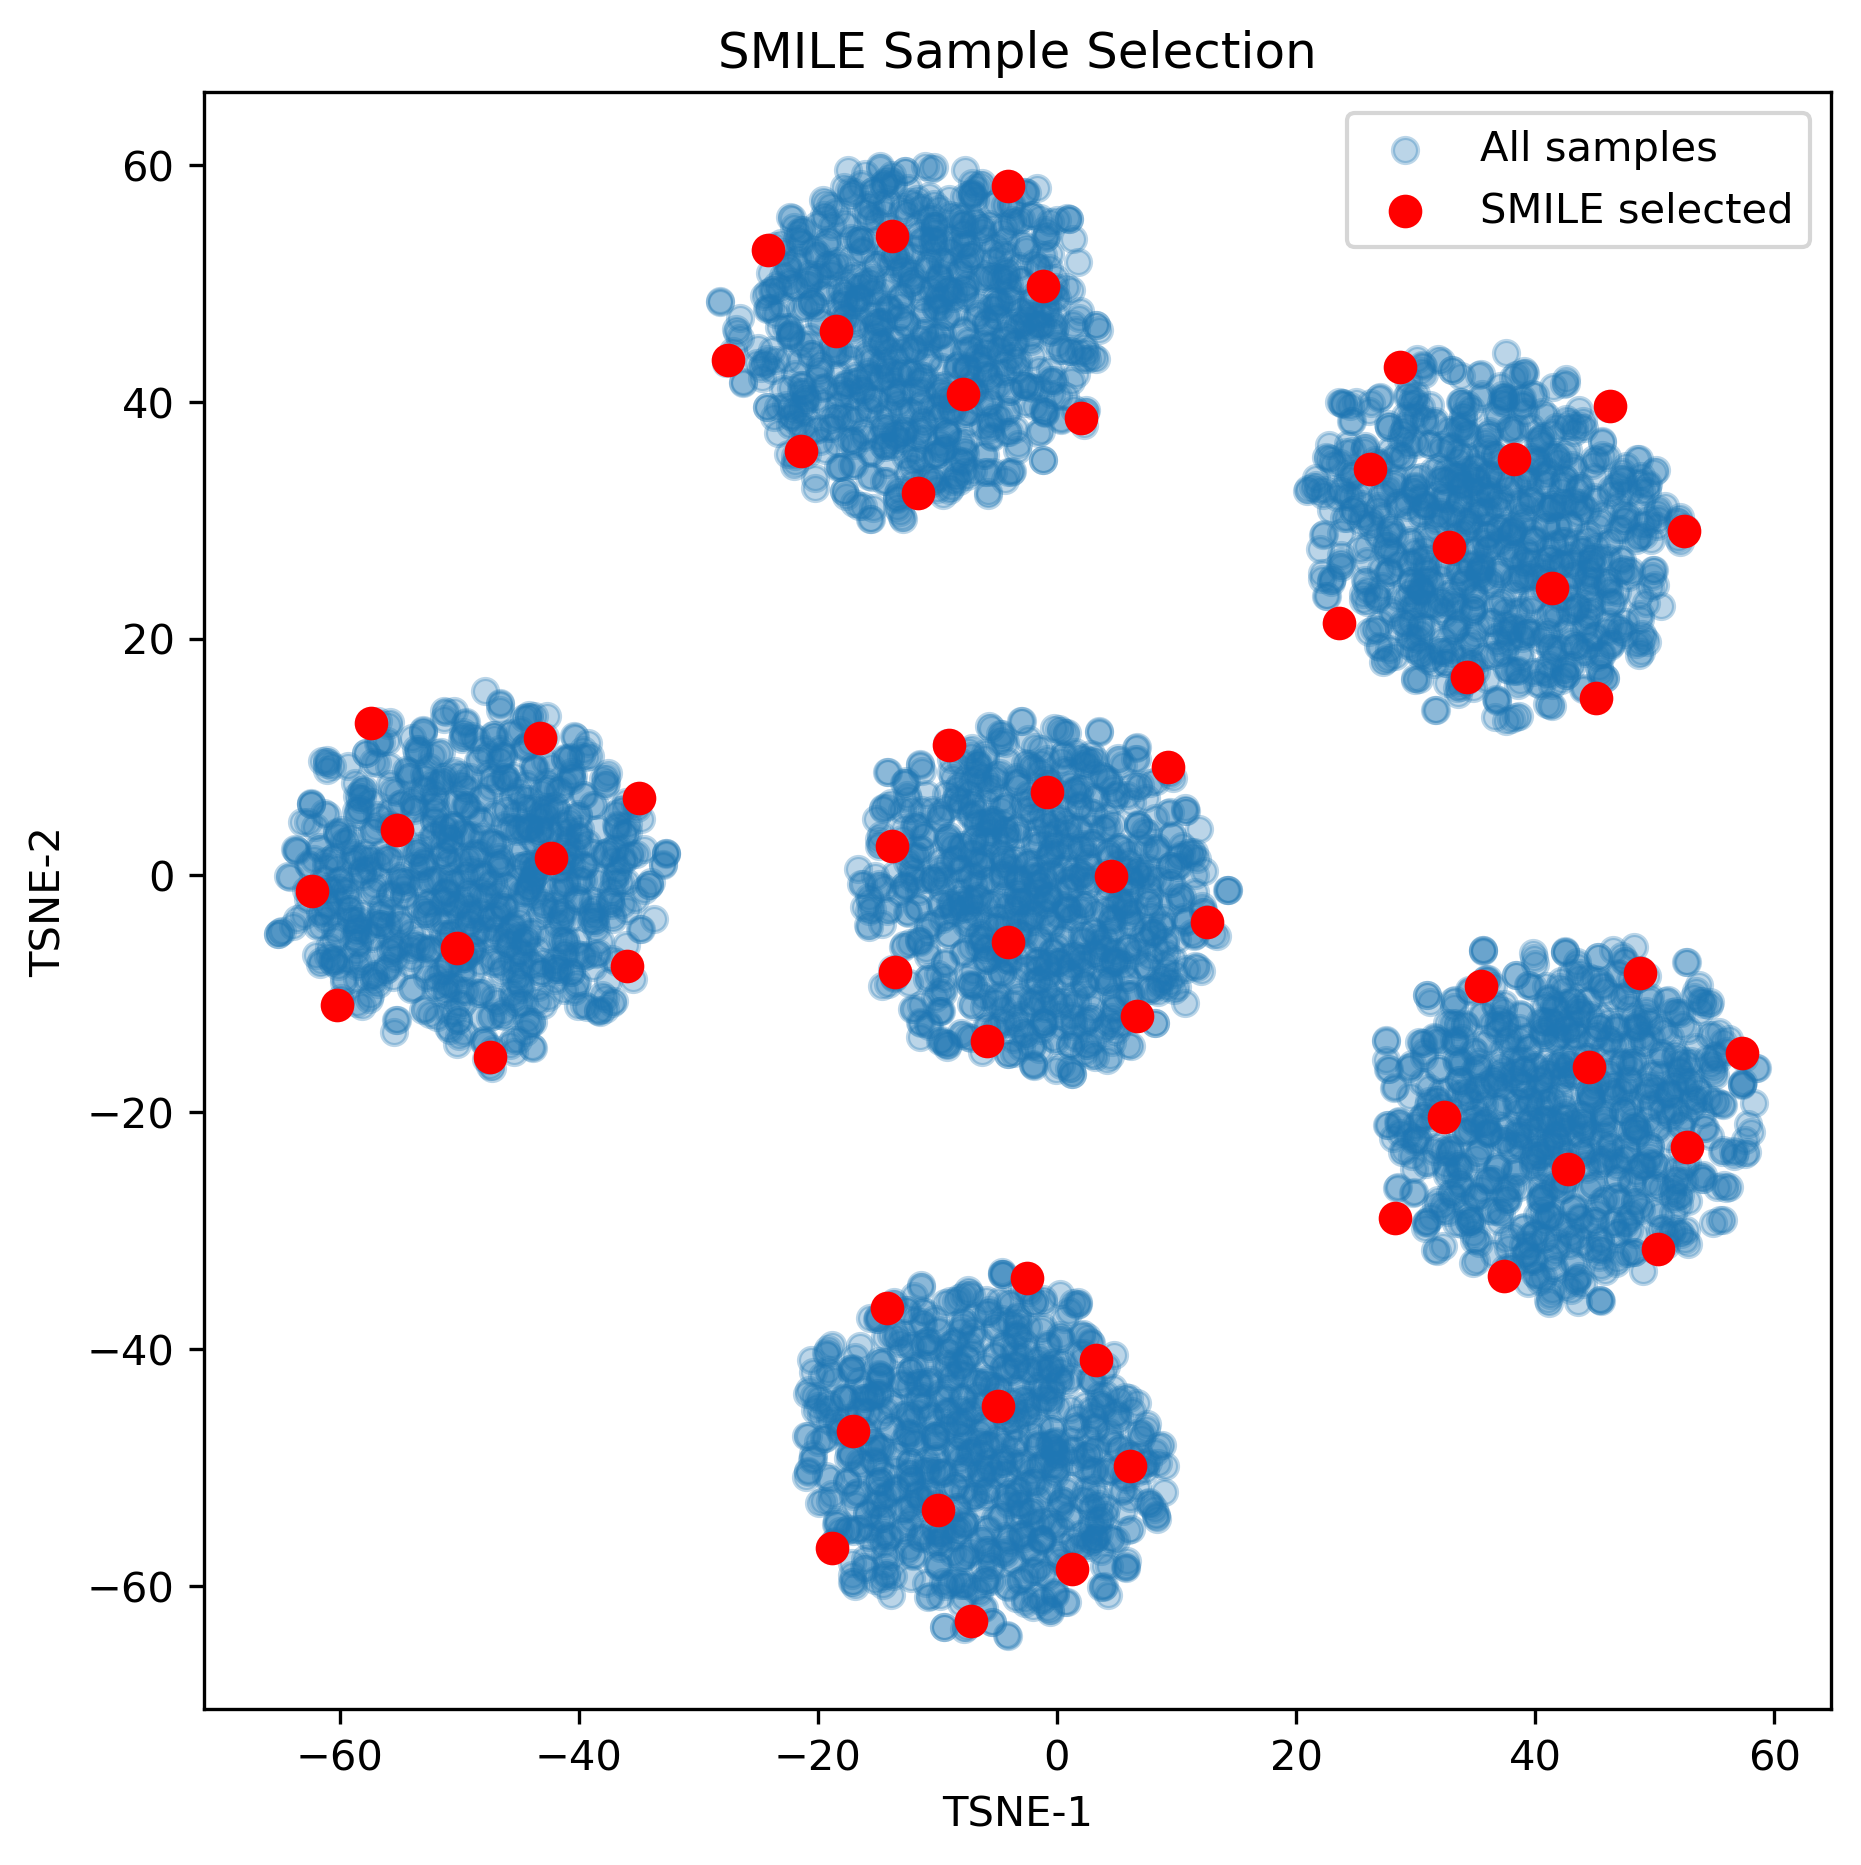

In [7]:
plt.figure(figsize=(7,7),dpi = 300)

#plot all points
plt.scatter(
    X_embedded[:,0],
    X_embedded[:,1],
    alpha=0.3,
    label="All samples"
)

#selected points
plt.scatter(
    X_embedded[selected_points,0],
    X_embedded[selected_points,1],
    color="red",
    s=50,
    label="SMILE selected"
)

plt.title("SMILE Sample Selection")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend()
plt.show()